# Introdução ao Machine Learning — notebook do minicurso

**Grupo PANDA · UFSCar · 2026**

## Parte 0 — Preparando o terreno

Vamos prever **evasão universitária**: quais alunos correm risco de abandonar o curso.

É um bom problema para aprender porque:

1. É **desbalanceado** — a maioria não evade. Isso quebra a acurácia, como veremos.
2. A ação que decorre dele é **limitada** — a coordenação só consegue ligar para um número
   finito de alunos. Isso força a discussão de limiar.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             precision_recall_curve)

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Tudo importado. Versões:")
print("  numpy       ", np.__version__)
print("  pandas      ", pd.__version__)

Tudo importado. Versões:
  numpy        2.0.2
  pandas       2.2.2


### Gerando os dados

A função abaixo cria 4.000 alunos fictícios.



In [ ]:
def gerar_dados(n=4000, seed=42):
    """Cria um dataset sintético de evasão universitária."""
    rng = np.random.default_rng(seed)

    nota_media     = np.clip(rng.normal(6.8, 1.6, n), 0, 10)
    frequencia     = np.clip(rng.normal(82, 13, n), 20, 100)
    horas_trabalho = np.clip(rng.gamma(2.0, 6.0, n), 0, 44).round()
    distancia_km   = np.clip(rng.gamma(2.0, 6.0, n), 0.5, 90).round(1)
    renda_sm       = np.clip(rng.lognormal(0.7, 0.7, n), 0.3, 25).round(1)
    tem_bolsa      = rng.binomial(1, 1 / (1 + np.exp((renda_sm - 3.0))))
    idade_ingresso = np.clip(rng.normal(19.5, 3.0, n), 16, 45).round().astype(int)
    semestre       = rng.integers(1, 11, n)
    extensao       = rng.binomial(1, 0.28, n)
    mudou_curso    = rng.binomial(1, 0.12, n)
    reprovacoes    = rng.poisson(np.clip(3.2 - 0.35 * nota_media, 0.05, None))

    z = (-2.15
         - 0.42  * (nota_media - 6.8)
         - 0.055 * (frequencia - 82)
         + 0.24  * reprovacoes
         + 0.035 * horas_trabalho
         + 0.011 * distancia_km
         - 0.10  * (renda_sm - 3.0)
         - 0.30  * tem_bolsa
         + 0.045 * (idade_ingresso - 19.5)
         - 0.055 * semestre
         - 0.55  * extensao
         + 0.45  * mudou_curso)
    evadiu = rng.binomial(1, 1 / (1 + np.exp(-z)))

    disc_prox_sem = np.where(
        evadiu == 1,
        rng.choice([0, 0, 0, 1], n),
        np.clip(rng.normal(5.2, 1.4, n).round(), 1, 9),
    ).astype(int)

    return pd.DataFrame({
        "nota_media": nota_media.round(2),
        "frequencia": frequencia.round(1),
        "disciplinas_reprovadas": reprovacoes,
        "horas_trabalho_semana": horas_trabalho.astype(int),
        "distancia_campus_km": distancia_km,
        "renda_familiar_sm": renda_sm,
        "tem_bolsa": tem_bolsa,
        "idade_ingresso": idade_ingresso,
        "semestre_atual": semestre,
        "participa_extensao": extensao,
        "mudou_de_curso": mudou_curso,
        "disciplinas_matriculadas_prox_semestre": disc_prox_sem,
        "evadiu": evadiu,
    })


df = gerar_dados()
print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (4000, 13)


,nota_media,frequencia,disciplinas_reprovadas,horas_trabalho_semana,distancia_campus_km,renda_familiar_sm,tem_bolsa,idade_ingresso,semestre_atual,participa_extensao,mudou_de_curso,disciplinas_matriculadas_prox_semestre,evadiu
0,7.29,85.3,0,13,12.9,5.5,0,20,10,1,1,6,0
1,5.14,93.6,1,8,9.9,1.3,1,16,2,1,0,4,0
2,8.00,85.6,1,7,12.3,2.3,1,16,4,1,0,4,0
3,8.30,100.0,0,1,3.3,2.3,1,18,3,0,0,6,0
4,3.68,100.0,0,5,5.4,1.5,1,26,9,0,0,4,0


In [ ]:
taxa = df["evadiu"].mean()

print(f"Evadiram:     {df['evadiu'].sum():>5}  ({taxa:.1%})")
print(f"Não evadiram: {(1 - df['evadiu']).sum():>5}  ({1 - taxa:.1%})")

Evadiram:       707  (17.7%)
Não evadiram:  3293  (82.3%)


---

# Parte 1 — Baseline e primeiro modelo

> **A pergunta desta parte:** quanto vale simplesmente *chutar*?


In [ ]:
baseline_acuracia = 1 - df["evadiu"].mean()

print(f"Acurácia de 'ninguém vai evadir': {baseline_acuracia:.1%}")

Acurácia de 'ninguém vai evadir': 82.3%


### Agora o modelo de verdade

Separamos os dados em treino e teste. O modelo aprende no treino e é avaliado no teste —
dados que ele **nunca viu**.

In [ ]:
FEATURES = [c for c in df.columns
            if c not in ("evadiu", "disciplinas_matriculadas_prox_semestre")]

X = df[FEATURES]
y = df["evadiu"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treino: {len(X_treino)} alunos")
print(f"Teste:  {len(X_teste)} alunos")
print(f"Features usadas: {len(FEATURES)}")

Treino: 3000 alunos
Teste:  1000 alunos
Features usadas: 11


In [ ]:
modelo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)
probabilidades = modelo.predict_proba(X_teste)[:, 1]

print(f"Baseline (chutar):     {baseline_acuracia:.1%}")
print(f"Regressão logística:   {accuracy_score(y_teste, previsoes):.1%}")
print()
print(f"Ganho: {accuracy_score(y_teste, previsoes) - baseline_acuracia:+.1%}")

Baseline (chutar):     82.3%
Regressão logística:   82.9%

Ganho: +0.6%


### Pare aqui e pense

O ganho foi de menos de 1 ponto percentual. Antes de concluir que o modelo é inútil,
olhe outras métricas.

In [ ]:
print(f"Acurácia: {accuracy_score(y_teste, previsoes):.3f}")
print(f"Precisão: {precision_score(y_teste, previsoes, zero_division=0):.3f}")
print(f"Recall:   {recall_score(y_teste, previsoes, zero_division=0):.3f}")
print(f"F1:       {f1_score(y_teste, previsoes, zero_division=0):.3f}")
print(f"ROC AUC:  {roc_auc_score(y_teste, probabilidades):.3f}-")
print()
print("O recall diz: de todos os alunos que evadiram, o modelo encontrou só 18%.")
print("Mas o ROC AUC (0.80) diz que o modelo ORDENA os alunos muito bem.")


Acurácia: 0.829
Precisão: 0.552
Recall:   0.181
F1:       0.272
ROC AUC:  0.799-

O recall diz: de todos os alunos que evadiram, o modelo encontrou só 18%.
Mas o ROC AUC (0.80) diz que o modelo ORDENA os alunos muito bem.


---

# Parte 2 — Overfitting e validação cruzada

> **A pergunta desta parte:** o modelo aprendeu, ou só decorou?

In [ ]:
profundidades = [2, 3, 5, 8, 12, 20, None]
acc_treino, acc_teste = [], []

for d in profundidades:
    arvore = DecisionTreeClassifier(max_depth=d, random_state=42)
    arvore.fit(X_treino, y_treino)
    acc_treino.append(arvore.score(X_treino, y_treino))
    acc_teste.append(arvore.score(X_teste, y_teste))
    rotulo = "sem limite" if d is None else str(d)
    print(f"max_depth={rotulo:>10}   treino={acc_treino[-1]:.3f}   teste={acc_teste[-1]:.3f}")

max_depth=         2   treino=0.823   teste=0.823
max_depth=         3   treino=0.827   teste=0.824
max_depth=         5   treino=0.845   teste=0.821
max_depth=         8   treino=0.885   teste=0.810
max_depth=        12   treino=0.953   teste=0.761
max_depth=        20   treino=1.000   teste=0.733
max_depth=sem limite   treino=1.000   teste=0.733


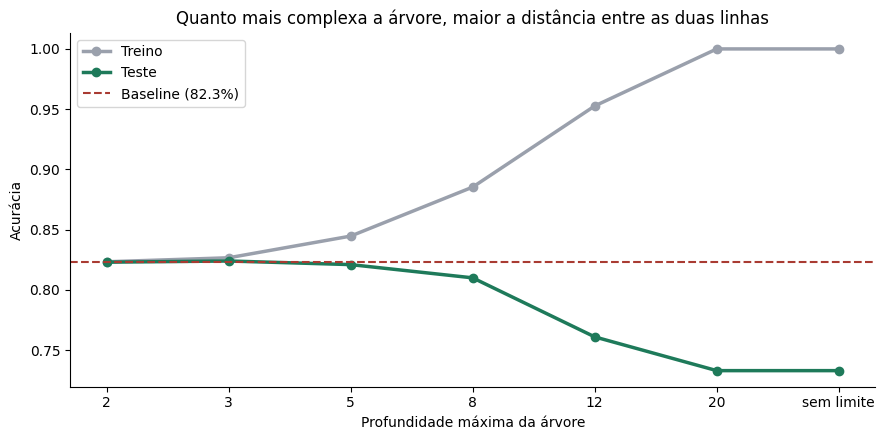

A árvore sem limite acerta 100% no treino — e fica ABAIXO da baseline no teste.


In [ ]:
rotulos = ["sem limite" if d is None else str(d) for d in profundidades]

fig, ax = plt.subplots()
ax.plot(rotulos, acc_treino, "o-", lw=2.5, label="Treino", color="#9AA0AC")
ax.plot(rotulos, acc_teste,  "o-", lw=2.5, label="Teste",  color="#1E7A5A")
ax.axhline(baseline_acuracia, ls="--", lw=1.5, color="#A93B32",
           label=f"Baseline ({baseline_acuracia:.1%})")
ax.set_xlabel("Profundidade máxima da árvore")
ax.set_ylabel("Acurácia")
ax.set_title("Quanto mais complexa a árvore, maior a distância entre as duas linhas")
ax.legend()
plt.tight_layout()
plt.show()

print("A árvore sem limite acerta 100% no treino — e fica ABAIXO da baseline no teste.")

### Uma divisão só pode mentir

Nós dividimos treino/teste **uma vez**, com `random_state=42`. E se esse sorteio tiver
dado sorte (ou azar)?

A validação cruzada refaz a divisão várias vezes e mostra o quanto o resultado varia.

In [ ]:
scores = cross_val_score(modelo, X, y, cv=5, scoring="roc_auc")

for i, s in enumerate(scores, 1):
    print(f"Dobra {i}: {s:.4f}")

print()
print(f"Média:          {scores.mean():.4f}")
print(f"Desvio padrão:  {scores.std():.4f}")
print(f"Pior x melhor:  {scores.min():.4f} a {scores.max():.4f}")
print()
print("Mesmo modelo, mesmos dados. A diferença é só qual pedaço caiu no teste.")
print("Por isso resultado sem desvio padrão não deveria convencer ninguém.")

Dobra 1: 0.7845
Dobra 2: 0.7576
Dobra 3: 0.8071
Dobra 4: 0.7849
Dobra 5: 0.7561

Média:          0.7781
Desvio padrão:  0.0191
Pior x melhor:  0.7561 a 0.8071

Mesmo modelo, mesmos dados. A diferença é só qual pedaço caiu no teste.
Por isso resultado sem desvio padrão não deveria convencer ninguém.


---

# Parte 3 — Métricas e limiar de decisão

> **A pergunta desta parte:** o modelo é bom **para quê**?

Esta é a parte mais importante do notebook.

In [ ]:
matriz = confusion_matrix(y_teste, previsoes)
vn, fp, fn, vp = matriz.ravel()

print("                    Previu: não evade   Previu: vai evadir")
print(f"Real: não evadiu         {vn:>6}              {fp:>6}")
print(f"Real: evadiu             {fn:>6}              {vp:>6}")
print()
print(f"{fn} alunos evadiram e o modelo os classificou como tranquilos.")
print(f"Isso é {fn / (fn + vp):.0%} de todos os evasores, passando batido.")
print()
print("A acurácia de 82,9% não sente esses alunos. Ela está ocupada")
print(f"comemorando os {vn} acertos na classe fácil.")

                    Previu: não evade   Previu: vai evadir
Real: não evadiu            797                  26
Real: evadiu                145                  32

145 alunos evadiram e o modelo os classificou como tranquilos.
Isso é 82% de todos os evasores, passando batido.

A acurácia de 82,9% não sente esses alunos. Ela está ocupada
comemorando os 797 acertos na classe fácil.


### O limiar de 0,5 não veio dos dados

Quando você chama `.predict()`, o scikit-learn usa 0,5 como corte: probabilidade acima
de 50% vira "vai evadir".

Esse 0,5 é um **valor padrão de biblioteca**.
Vamos mexer nele.

In [ ]:
limiares = np.arange(0.05, 0.96, 0.05)
precisoes, recalls, n_contatos = [], [], []

for t in limiares:
    pred_t = (probabilidades >= t).astype(int)
    precisoes.append(precision_score(y_teste, pred_t, zero_division=0))
    recalls.append(recall_score(y_teste, pred_t, zero_division=0))
    n_contatos.append(pred_t.sum())

tabela = pd.DataFrame({
    "limiar": limiares.round(2),
    "alunos_contatados": n_contatos,
    "precisao": np.round(precisoes, 3),
    "recall": np.round(recalls, 3),
})
tabela[tabela.limiar <= 0.55]

,limiar,alunos_contatados,precisao,recall
0,0.05,823,0.213,0.989
1,0.10,605,0.263,0.898
2,0.15,452,0.321,0.819
3,0.20,318,0.381,0.684
4,0.25,242,0.442,0.605
5,0.30,192,0.490,0.531
6,0.35,149,0.490,0.412
7,0.40,110,0.536,0.333
8,0.45,79,0.570,0.254
9,0.50,58,0.552,0.181


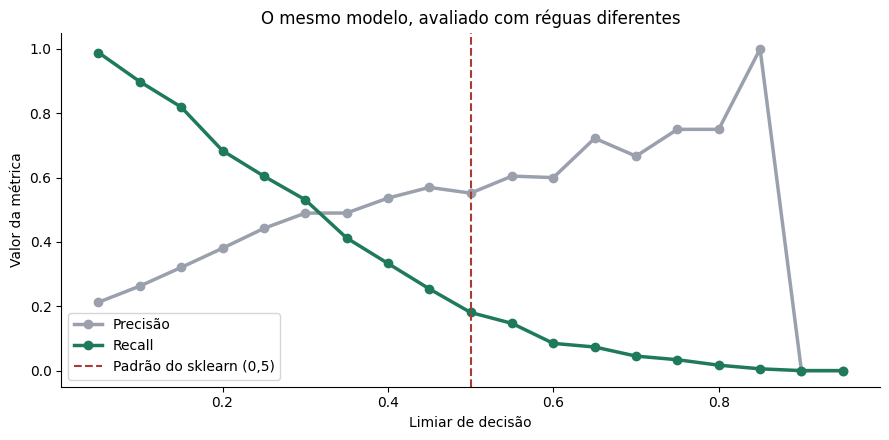

Recall com limiar 0,50: 18.1%
Recall com limiar 0,15: 81.9%

Não treinamos nada de novo. Só mudamos onde cortar.


In [ ]:
fig, ax = plt.subplots()
ax.plot(limiares, precisoes, "o-", lw=2.5, label="Precisão", color="#9AA0AC")
ax.plot(limiares, recalls,   "o-", lw=2.5, label="Recall",   color="#1E7A5A")
ax.axvline(0.5, ls="--", lw=1.5, color="#A93B32", label="Padrão do sklearn (0,5)")
ax.set_xlabel("Limiar de decisão")
ax.set_ylabel("Valor da métrica")
ax.set_title("O mesmo modelo, avaliado com réguas diferentes")
ax.legend()
plt.tight_layout()
plt.show()

rec_015 = recall_score(y_teste, (probabilidades >= 0.15).astype(int), zero_division=0)
print(f"Recall com limiar 0,50: {recalls[list(limiares.round(2)).index(0.5)]:.1%}")
print(f"Recall com limiar 0,15: {rec_015:.1%}")
print()
print("Não treinamos nada de novo. Só mudamos onde cortar.")

### A pergunta que a coordenação realmente faz

Ninguém pergunta "qual a acurácia?". Perguntam: *"eu consigo ligar para 100 alunos esta
semana. Quais?"*

Isso muda tudo. Você não escolhe o limiar — você escolhe a **capacidade**, e o limiar
sai dela.

In [ ]:
CAPACIDADE = 100

ordem = np.argsort(-probabilidades)
top = ordem[:CAPACIDADE]
y_arr = y_teste.to_numpy()

acertos_modelo = y_arr[top].sum()
taxa_base = y_arr.mean()
esperado_sorteio = CAPACIDADE * taxa_base

print(f"Sorteando {CAPACIDADE} alunos ao acaso: ~{esperado_sorteio:.0f} evasores encontrados")
print(f"Pegando os {CAPACIDADE} mais prováveis:  {acertos_modelo} evasores encontrados")
print()
print(f"O modelo é {acertos_modelo / esperado_sorteio:.1f}x mais eficiente que sortear,")
print("com o mesmo esforço e o mesmo orçamento.")
print()
print("Sobrou a única pergunta que importa: quanto melhor que o processo atual?")

Sorteando 100 alunos ao acaso: ~18 evasores encontrados
Pegando os 100 mais prováveis:  54 evasores encontrados

O modelo é 3.1x mais eficiente que sortear,
com o mesmo esforço e o mesmo orçamento.

Sobrou a única pergunta que importa: quanto melhor que o processo atual?


---

# Parte 4 — Vazamento de dados

> **A pergunta desta parte:** e se o resultado for bom demais?

Lembra da coluna que excluímos lá no começo? `disciplinas_matriculadas_prox_semestre`.

Vamos colocá-la de volta e ver o que acontece.

In [ ]:
FEATURES_COM_VAZAMENTO = FEATURES + ["disciplinas_matriculadas_prox_semestre"]

Xv = df[FEATURES_COM_VAZAMENTO]
Xv_treino, Xv_teste, yv_treino, yv_teste = train_test_split(
    Xv, y, test_size=0.25, random_state=42, stratify=y
)

modelo_vazado = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_vazado.fit(Xv_treino, yv_treino)
pred_v = modelo_vazado.predict(Xv_teste)

print("=== COM a coluna extra ===")
print(f"Acurácia: {accuracy_score(yv_teste, pred_v):.1%}")
print(f"Recall:   {recall_score(yv_teste, pred_v):.1%}")
print(f"ROC AUC:  {roc_auc_score(yv_teste, modelo_vazado.predict_proba(Xv_teste)[:, 1]):.4f}")

=== COM a coluna extra ===
Acurácia: 99.8%
Recall:   100.0%
ROC AUC:  0.9992


### Por que é inútil

Quem evade **não se matricula** no semestre seguinte. A coluna não *prevê* a evasão —
ela **é** a evasão, escrita de outro jeito.

No dia em que você precisa da previsão (para poder agir a tempo), essa coluna ainda
está vazia. O modelo de 99,8% não pode ser usado nem uma única vez.

### Como detectar isso na prática

In [ ]:
importancias = pd.Series(
    modelo_vazado.feature_importances_,
    index=FEATURES_COM_VAZAMENTO
).sort_values(ascending=False)

print("Importância das features:")
print(importancias.head(6).round(4).to_string())
print()
print(f"Uma única coluna concentra {importancias.iloc[0]:.0%} da importância do modelo.")
print()
print("Esse é o formato típico de um vazamento — e é fácil de checar.")
print("Regra prática: se o resultado te surpreendeu para cima, procure o vazamento")

Importância das features:
disciplinas_matriculadas_prox_semestre    0.8327
nota_media                                0.0435
frequencia                                0.0350
distancia_campus_km                       0.0163
horas_trabalho_semana                     0.0163
disciplinas_reprovadas                    0.0154

Uma única coluna concentra 83% da importância do modelo.

Esse é o formato típico de um vazamento — e é fácil de checar.
Regra prática: se o resultado te surpreendeu para cima, procure o vazamento


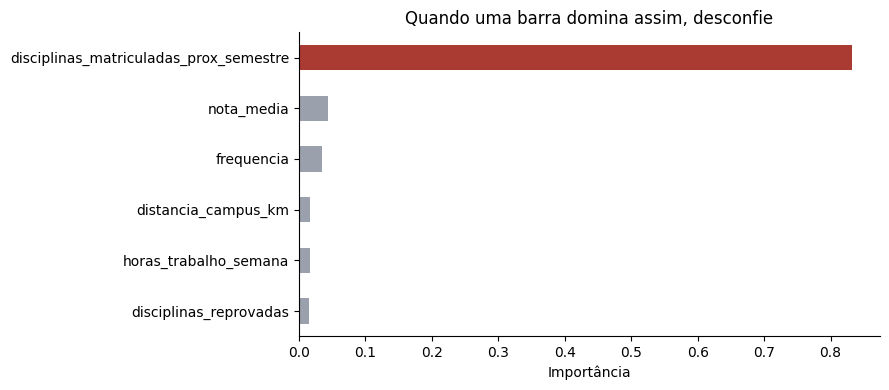

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
cores = ["#A93B32"] + ["#9AA0AC"] * 5
importancias.head(6)[::-1].plot(kind="barh", ax=ax, color=cores[::-1])
ax.set_xlabel("Importância")
ax.set_title("Quando uma barra domina assim, desconfie")
plt.tight_layout()
plt.show()

---

# Agora é com você

O resumo do minicurso em quatro perguntas. Faça as quatro em **todo** projeto de ML
que você tocar:

| Pergunta | Por quê |
|---|---|
| **Comparado com o quê?** | Sem baseline, um número alto não significa nada. |
| **Medido como?** | A métrica vem da decisão, não o contrário. |
| **Onde eu corto?** | O limiar é uma escolha organizacional, não estatística. |
| **Bom demais?** | Resultado surpreendente é suspeito até prova em contrário. |

### Exercício final

Pegue **um dataset seu** — do projeto guiado, do Kaggle, de onde vier — e responda
as quatro perguntas acima antes de treinar qualquer coisa.

Se você não conseguir responder a primeira, você ainda não tem um projeto de ML.
Você tem um dataset.